# Identifier les variables influencant les comportements des courbes de charge

But : déterminer les variables qui influent sur le comportement des courbes de charge au inter et intra régions

In [446]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from random import randint
import seaborn as sns

# Racine du projet — 2 niveaux au-dessus de ce notebook
# notebooks/03_visualisation/ -> notebooks/ -> FlexiMax/
ROOT = Path().resolve().parent.parent

DATA_RAW       = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'
FIGURES        = ROOT / 'reports' / 'figures'

print('Racine projet :', ROOT)
df_metadata = pd.read_parquet(DATA_PROCESSED / 'metadata_features.parquet')

Racine projet : C:\Users\eassoumou1\FlexiMax


In [198]:
df_metadata["in.ashrae_iecc_climate_zone_2004"].nunique()

17

            PROCEDE : 
            -   On prend 3 bâtiments répondant aux critères par zone ASHRAE (17 zones)
            -   On modélise graphiquement leur courbe de charge quotidienne par minute sur le même graphique
            -   On étudie les différences entre bâtiments au sein d'une même zone ASHRAE
                    -   Différence ponctuelle
                    -   EQM
                    -   Valeurs remarquables (min, max, x=0)
                    -   Intersections 
            -   Etude des corrélations entre variables de df_metadata numérique :
                    -   Calcul des coefficients de Pearson
                    -   Visualisations des corrélations
                    -   Matrice des pvaleurs et visualisation
            -   On étudie les différences entre bâtiments moyens de chaque zone ASHRAE pour comprendre l'influence du climat sur les motifs de consommation 
                    -   Tracé des fonctions sur le même graphique 
                    -   Différence ponctuelle, EQM, valeurs remarquables
                    -   Regression linéaire multiple en fonction des variables explicatives trouvées à l'étape précédente


### I. Différences et similitudes entre 3 bâtiments de la même zone ASHRAE

Filtrage de la dataframe pour ne garder que les bâtiments répondant à nos critères

In [199]:
df_metadataF = df_metadata[df_metadata['in.misc_pool']!='Has Pool']
df_metadataF = df_metadataF[df_metadataF['in.electric_vehicle_ownership']==0]
df_metadataF = df_metadataF[df_metadataF['in.has_pv']==0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.heating.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.electricity.total.energy_consumption..kwh']!=0]
df_metadataF = df_metadataF[df_metadataF['out.fuel_oil.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.natural_gas.total.energy_consumption..kwh']==0]
df_metadataF = df_metadataF[df_metadataF['out.propane.total.energy_consumption..kwh']==0]
df_metadataF

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
3,4,Success,0,Baseline,253.903673,True,854.0,43219.0,Lubbock County,Non-CBSA West South Central,...,0.0,0.0,0.0,11.668278,11.668278,0.0,0.0,0.0,0,1
7,8,Success,0,Baseline,253.903673,True,854.0,41362.0,Knox County,Non-CBSA East South Central,...,0.0,0.0,0.0,8.757471,8.757471,0.0,0.0,0.0,0,1
13,14,Success,0,Baseline,253.903673,True,1698.0,5484.0,Canyon County,Non-CBSA Mountain,...,0.0,0.0,0.0,12.588248,12.588248,0.0,0.0,0.2,0,3
14,15,Success,0,Baseline,253.903673,True,881.0,940.0,Duval County,Non-CBSA South Atlantic,...,0.0,0.0,0.0,21.882529,21.882529,0.0,0.0,0.2,0,4
17,18,Success,0,Baseline,253.903673,True,881.0,NaN,Cass County,Non-CBSA West South Central,...,0.0,0.0,0.0,7.701349,7.701349,0.0,0.0,0.3,8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549938,549968,Success,0,Baseline,253.903673,True,1698.0,55156.0,Price County,Non-CBSA East North Central,...,0.0,0.0,0.0,34.424287,34.424287,0.0,0.0,0.2,0,4
549941,549971,Success,0,Baseline,253.903673,True,1138.0,53538.0,Harris County,"CBSA Houston-The Woodlands-Sugar Land, TX",...,0.0,0.0,0.0,10.416900,10.416900,0.0,0.0,0.0,0,1
549947,549977,Success,0,Baseline,253.903673,True,854.0,16241.0,Camden County,"CBSA Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",...,0.0,0.0,0.0,13.690949,13.690949,0.0,0.0,NaN,0,0
549966,549996,Success,0,Baseline,253.903673,True,872.0,15234.0,Story County,Non-CBSA West North Central,...,0.0,0.0,0.0,23.041369,23.041369,0.0,0.0,0.2,0,4


Téléchargement de 3 bâtiments répondant aux critères par zone

In [200]:
ASHRAE_zones = df_metadata["in.ashrae_iecc_climate_zone_2004"].sort_values().unique()
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B', '8AK']
Length: 17, dtype: str

In [201]:
df_single_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="3A"].reset_index(drop=True)
df_single_zone

,bldg_id,completed_status,upgrade,in.upgrade_name,weight,applicability,in.sqft..ft2,in.representative_income,in.county_name,in.ahs_region,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
0,1,Success,0,Baseline,253.903673,True,1228.0,53672.0,Franklin County,Non-CBSA East South Central,...,0.0,0.0,2.331442,13.537354,13.537354,0.0,0.0,0.0,0,1
1,18,Success,0,Baseline,253.903673,True,881.0,NaN,Cass County,Non-CBSA West South Central,...,0.0,0.0,0.000000,7.701349,7.701349,0.0,0.0,0.3,8,6
2,33,Success,0,Baseline,253.903673,True,634.0,12022.0,Mecklenburg County,Non-CBSA South Atlantic,...,0.0,0.0,0.000000,17.041112,17.041112,0.0,0.0,NaN,0,0
3,43,Success,0,Baseline,253.903673,True,1228.0,64828.0,Clayton County,"CBSA Atlanta-Sandy Springs-Roswell, GA",...,0.0,0.0,0.000000,18.336989,18.336989,0.0,0.0,0.2,4,6
4,44,Success,0,Baseline,253.903673,True,1228.0,75632.0,Comanche County,Non-CBSA West South Central,...,0.0,0.0,0.000000,12.620194,12.620194,0.0,0.0,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73172,549934,Success,0,Baseline,253.903673,True,1698.0,359796.0,Jefferson County,Non-CBSA East South Central,...,0.0,0.0,0.000000,15.040690,15.040690,0.0,0.0,0.3,4,6
73173,549937,Success,0,Baseline,253.903673,True,634.0,61268.0,Comanche County,Non-CBSA West South Central,...,0.0,0.0,0.000000,29.314965,29.314965,0.0,0.0,0.3,4,6
73174,549949,Success,0,Baseline,253.903673,True,854.0,68076.0,Shelby County,Non-CBSA East South Central,...,0.0,0.0,0.000000,6.690188,6.690188,0.0,0.0,0.0,0,1
73175,549963,Success,0,Baseline,253.903673,True,1228.0,22569.0,Putnam County,Non-CBSA South Atlantic,...,0.0,0.0,0.000000,17.137975,17.137975,0.0,0.0,0.2,4,6


In [202]:
# Télecharger les séries temporelles par bâtiment depuis le data lake public OEDI (ResStock 2025, AMY2018)

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_RAW       = ROOT / 'data' / 'raw'

OEDI_BASE = (
    'https://oedi-data-lake.s3.amazonaws.com/'
    'nrel-pds-building-stock/end-use-load-profiles-for-us-building-stock/'
    '2025/resstock_amy2018_release_1/'
    'timeseries_individual_buildings/by_state/upgrade=0'
)

def download_timeseries(bldg_id: int, state: str, save: bool = True) -> pd.DataFrame:
    out = DATA_RAW / f'{bldg_id}-0.parquet'
    if out.exists():    #si le fichier existe déjà on charge localement sans retélécharger
        print(f'Fichier existant trouvé, chargement local : {out}')
        df = pd.read_parquet(out)
    else:
        url = f'{OEDI_BASE}/state={state}/{bldg_id}-0.parquet'
        print(f'Téléchargement : {url}')
        df = pd.read_parquet(url)
        if save:
            #out.parent.mkdir(parents=True, exist_ok=True) 
            df.to_parquet(out)
            print(f'Sauvegardé : {out}')
    print(f'Shape : {df.shape} | {df["timestamp"].iloc[0]} → {df["timestamp"].iloc[-1]}')
    return df

In [203]:
df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="3A"].reset_index(drop=True)

random_index = randint(0,df_zone.shape[0])
chosen_building = (df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
print(chosen_building)

(np.int64(116432), 'AL', True)


            Attention : cette prochaine cellule télécharge 51 fichiers
            Enlever les guillemets pour l'executer (2min23sec)

In [204]:
#A ne pas executer (les valeurs aléatoires générées par ce code sont téléchargeables dans les cellules en dessous)
"""dataframes = []
acc_zones = 0
acc_df = 0
for e in ASHRAE_zones :
    df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)
    acc_zones +=1
    for i in range(3):
        random_index = randint(0,df_zone.shape[0])
        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)
        dataframes.append(df_dwnld)
        acc_df += 1
"""

'dataframes = []\nacc_zones = 0\nacc_df = 0\nfor e in ASHRAE_zones :\n    df_zone = df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]==e].reset_index(drop=True)\n    acc_zones +=1\n    for i in range(3):\n        random_index = randint(0,df_zone.shape[0])\n        df_dwnld = download_timeseries(df_zone["bldg_id"].loc[random_index], df_zone["in.state"].loc[random_index], True)\n        dataframes.append(df_dwnld)\n        acc_df += 1\n'

In [205]:
"""print("Nombre de dataframes téléchargés : "+str(acc_df))
print("Nombre de zones différentes téléchargées : "+str(acc_zones))"""

'print("Nombre de dataframes téléchargés : "+str(acc_df))\nprint("Nombre de zones différentes téléchargées : "+str(acc_zones))'

In [206]:
"""data = []
for i in range(len(dataframes)):
    data.append(int(dataframes[i]["bldg_id"][0]))
data1=[]
for e in data :
    data1.append(df_metadata["in.state"].loc[df_metadata["bldg_id"]==e].iloc[0])
print(data)
print(data1)"""

'data = []\nfor i in range(len(dataframes)):\n    data.append(int(dataframes[i]["bldg_id"][0]))\ndata1=[]\nfor e in data :\n    data1.append(df_metadata["in.state"].loc[df_metadata["bldg_id"]==e].iloc[0])\nprint(data)\nprint(data1)'

In [207]:
dataframes_ids = [515777, 32720, 47526, 187111, 547571, 439033, 535975, 103278, 416708, 219021, 305448, 358653, 445781, 536952, 140479, 282481, 211039, 549429, 189821, 332813, 67620, 360466, 371530, 137306, 179622, 264540, 221745, 518700, 453671, 460575, 315734, 10485, 330117, 235930, 463533, 5887, 165350, 198999, 39270, 269793, 288767, 35334, 288276, 131442, 255720, 238101, 406739, 87816, 352239, 490118, 473623]
dataframes_states = ['HI', 'FL', 'FL', 'FL', 'LA', 'FL', 'AZ', 'AZ', 'AZ', 'SC', 'AR', 'AR', 'CA', 'CA', 'CA', 'CA', 'CA', 'CA', 'VA', 'OH', 'DC', 'NM', 'NM', 'TX', 'WA', 'OR', 'WA', 'OH', 'MI', 'IN', 'WA', 'ID', 'ID', 'WI', 'WI', 'MI', 'ID', 'WY', 'WY', 'MN', 'MN', 'MI', 'AK', 'AK', 'AK', 'CO', 'CO', 'CO', 'AK', 'AK', 'AK']

In [208]:
out = DATA_RAW / f'{189821}-0.parquet'
out.exists()

True

In [209]:
dataframes = []
for i in range(len(dataframes_ids)):
    df_dwnld = download_timeseries(dataframes_ids[i], dataframes_states[i])
    dataframes.append(df_dwnld)

dataframes[0].head(10)

Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\515777-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\32720-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\47526-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\187111-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\547571-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant trouvé, chargement local : C:\Users\eassoumou1\FlexiMax\data\raw\439033-0.parquet
Shape : (35040, 192) | 2018-01-01 00:15:00 → 2019-01-01 00:00:00
Fichier existant t

,bldg_id,timestamp,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
0,515777,2018-01-01 00:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.751,0.0,0.0,0.75,NaN,0.870,0.572,0.0,NaN,0.0
1,515777,2018-01-01 00:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.751,0.0,0.0,0.75,NaN,0.870,0.572,0.0,NaN,0.0
2,515777,2018-01-01 00:45:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.891,0.0,0.0,0.90,NaN,0.932,0.684,0.0,NaN,0.0
3,515777,2018-01-01 01:00:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.971,0.0,0.0,1.00,NaN,0.950,0.864,0.0,NaN,0.0
4,515777,2018-01-01 01:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
5,515777,2018-01-01 01:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
6,515777,2018-01-01 01:45:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.962,0.0,0.0,1.00,NaN,0.934,0.936,0.0,NaN,0.0
7,515777,2018-01-01 02:00:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.850,0.0,0.0,1.00,NaN,0.888,0.906,0.0,NaN,0.0
8,515777,2018-01-01 02:15:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.776,0.0,0.0,1.00,NaN,0.857,0.887,0.0,NaN,0.0
9,515777,2018-01-01 02:30:00,3310.000244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.667,0.0,0.0,1.00,NaN,0.812,0.756,0.0,NaN,0.0


Visualisation des courbes de charge par zone ASHRAE

            Chaque groupe de 3 bâtiments dans dataframes appartient à une même zone, dans l'ordre de ASHRAE_zones

In [210]:
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B', '8AK']
Length: 17, dtype: str

In [211]:
for i in range(3):
    if df_metadata[df_metadata["in.ashrae_iecc_climate_zone_2004"]=="1A"].loc[df_metadata["bldg_id"]==dataframes[i]["bldg_id"].iloc[0]].size != 0:
        print("Correct zone 1A")
    else:
        print("Wrong zones")

Correct zone 1A
Correct zone 1A
Correct zone 1A


In [299]:
for i in range(len(ASHRAE_zones)*3):
    dataframes[i]["minute"] = dataframes[i]["timestamp"].dt.minute + dataframes[i]["timestamp"].dt.hour*60
    dataframes[i]["date"] = dataframes[i]["timestamp"].dt.date


In [213]:
def make_3_curb_emission_plot(a,b,c):
    df0 = dataframes[a].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
    df1 = dataframes[b].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()
    df2 = dataframes[c].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean()

    plt.figure(figsize=(8,5))

    plt.plot(df0.index, df0.values, marker=".", color='darkblue', label="Building "+str(dataframes[a]["bldg_id"].loc[3]))
    plt.plot(df1.index, df1.values, marker=".", color='darkred', label="Building "+str(dataframes[b]["bldg_id"].loc[3]))
    plt.plot(df2.index, df2.values, marker=".", color='darkgreen', label="Building "+str(dataframes[c]["bldg_id"].loc[3]))

    plt.xlabel("Time of Day (Minutes, 1440min=24h)")
    plt.ylabel("Electricity Consumption (kWh)")
    plt.yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2])

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    return

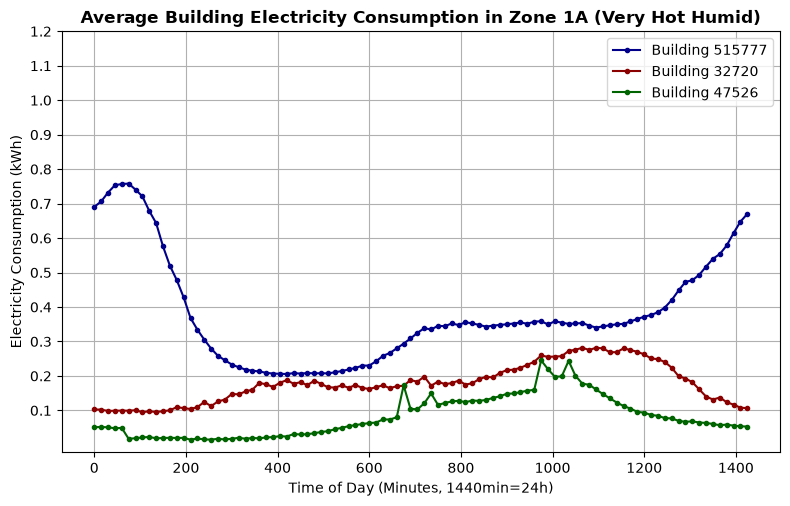

In [214]:
make_3_curb_emission_plot(0,1,2)
plt.title('Average Building Electricity Consumption in Zone 1A (Very Hot Humid)', fontsize=12, fontweight='bold')
plt.show()

In [215]:
print("EMISSION DIFFERENCE :")
print ("Household 51577 maximum : "+ str(dataframes[0].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print ("Household 32720 maximum : "+ str(dataframes[1].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print("Household 47526 maximum : "+str(dataframes[2].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()))
print("At it's maximum, household 51577 consumes "+ str(dataframes[0].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max()/dataframes[1].groupby("minute")["out.electricity.total.energy_consumption..kwh"].mean().max())+" times more than household 32720")
print("\n")
print("HOUSEHOLD INCOME : ")
print("Household 51577 : "+str(df_metadata["in.income"].loc[df_metadata["bldg_id"]==515777].iloc[0]))
print("Household 32720 : "+str(df_metadata["in.income"].loc[df_metadata["bldg_id"]==32720].iloc[0]))
print("Household 47526 : "+str(df_metadata["in.income"].loc[df_metadata["bldg_id"]==47526].iloc[0]))
print("--> Household 515777 earns "+str(df_metadata["in.income"].loc[df_metadata["bldg_id"]==515777].iloc[0]/df_metadata["in.income"].loc[df_metadata["bldg_id"]==32720].iloc[0])+" times more than houselhold 32720")
print("\n")
print("NUMBER OF OCCUPANTS :")
print("Household 51577 : "+str(df_metadata["in.occupants"].loc[df_metadata["bldg_id"]==515777].iloc[0]))
print("Household 32720 : "+str(df_metadata["in.occupants"].loc[df_metadata["bldg_id"]==32720].iloc[0]))
print("Household 47526 : "+str(df_metadata["in.occupants"].loc[df_metadata["bldg_id"]==47526].iloc[0]))
print("\n")

EMISSION DIFFERENCE :
Household 51577 maximum : 0.75804836
Household 32720 maximum : 0.28186503
Household 47526 maximum : 0.24518426
At it's maximum, household 51577 consumes 2.6894019 times more than household 32720


HOUSEHOLD INCOME : 
Household 51577 : 149999.5
Household 32720 : 5000.0
Household 47526 : nan
--> Household 515777 earns 29.9999 times more than houselhold 32720


NUMBER OF OCCUPANTS :
Household 51577 : 4.0
Household 32720 : 2.0
Household 47526 : 0.0




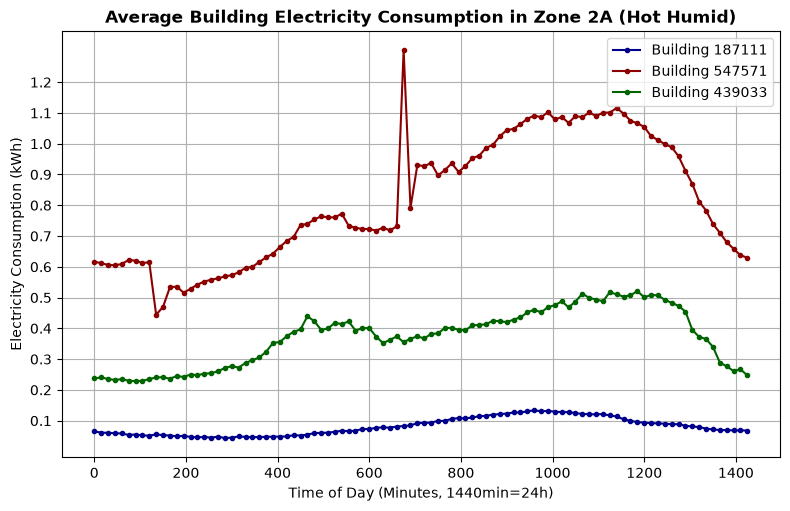

In [216]:
make_3_curb_emission_plot(3,4,5)
plt.title('Average Building Electricity Consumption in Zone 2A (Hot Humid)', fontsize=12, fontweight='bold')
plt.show()

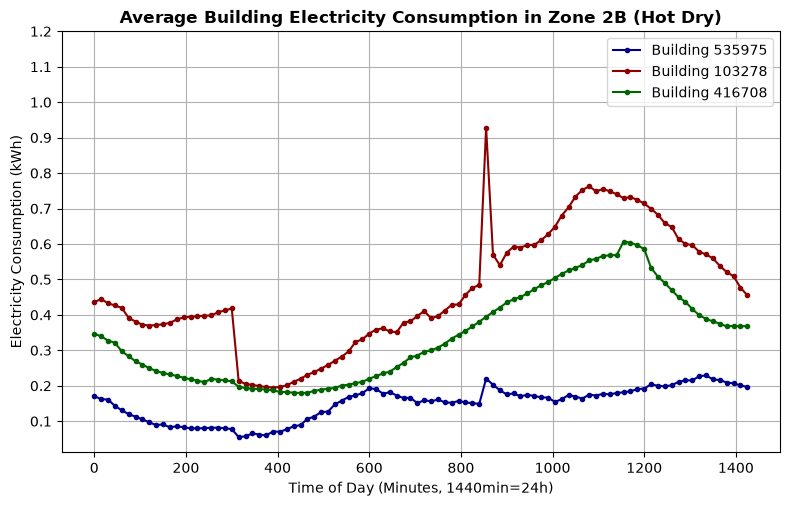

In [217]:
make_3_curb_emission_plot(6,7,8)
plt.title('Average Building Electricity Consumption in Zone 2B (Hot Dry)', fontsize=12, fontweight='bold')
plt.show()

In [218]:
ASHRAE_zones

<ArrowStringArray>
[ '1A',  '2A',  '2B',  '3A',  '3B',  '3C',  '4A',  '4B',  '4C',  '5A',  '5B',
  '6A',  '6B',  '7A', '7AK',  '7B', '8AK']
Length: 17, dtype: str

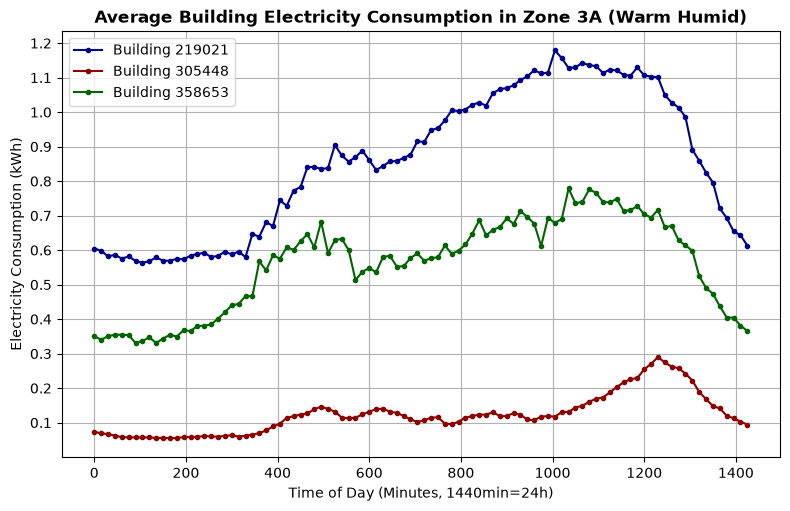

In [219]:
make_3_curb_emission_plot(9,10,11)
plt.title('Average Building Electricity Consumption in Zone 3A (Warm Humid)', fontsize=12, fontweight='bold')
plt.show()

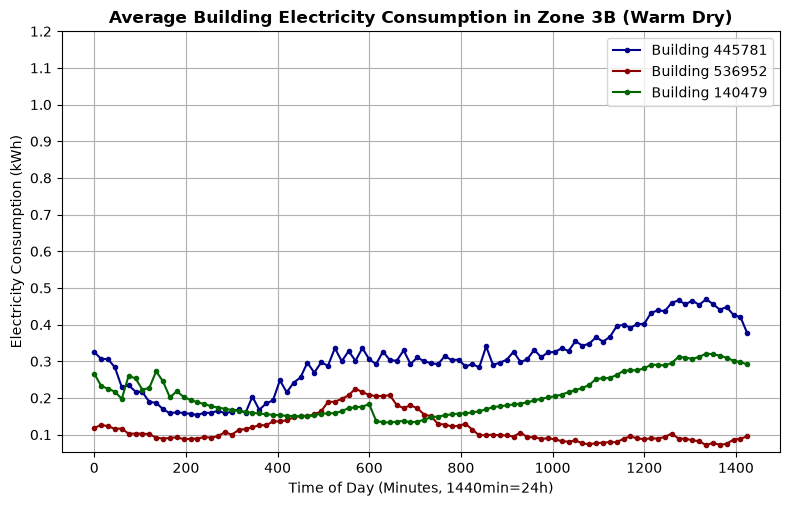

In [220]:
make_3_curb_emission_plot(12,13,14)
plt.title('Average Building Electricity Consumption in Zone 3B (Warm Dry)', fontsize=12, fontweight='bold')
plt.show()

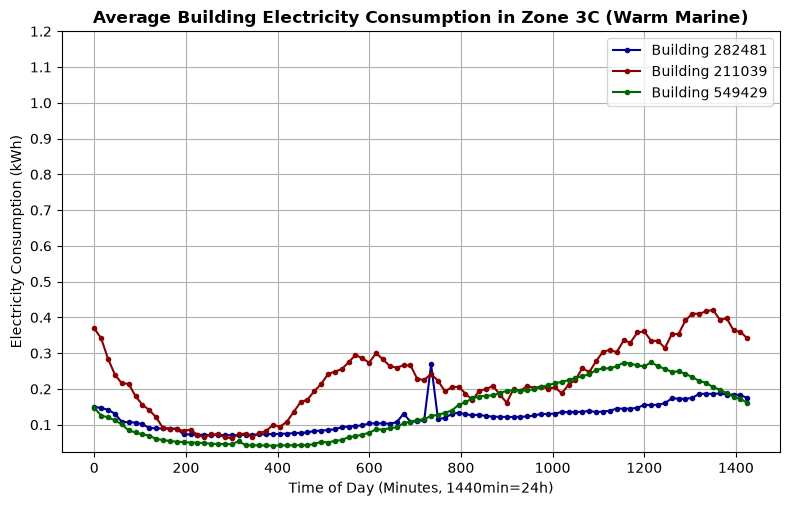

In [222]:
make_3_curb_emission_plot(15,16,17)
plt.title('Average Building Electricity Consumption in Zone 3C (Warm Marine)', fontsize=12, fontweight='bold')
plt.show()

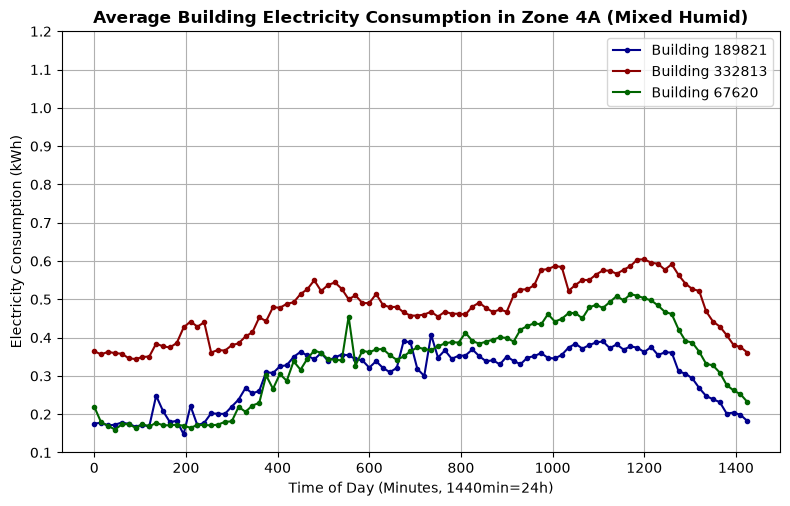

In [223]:
make_3_curb_emission_plot(18,19,20)
plt.title('Average Building Electricity Consumption in Zone 4A (Mixed Humid)', fontsize=12, fontweight='bold')
plt.show()

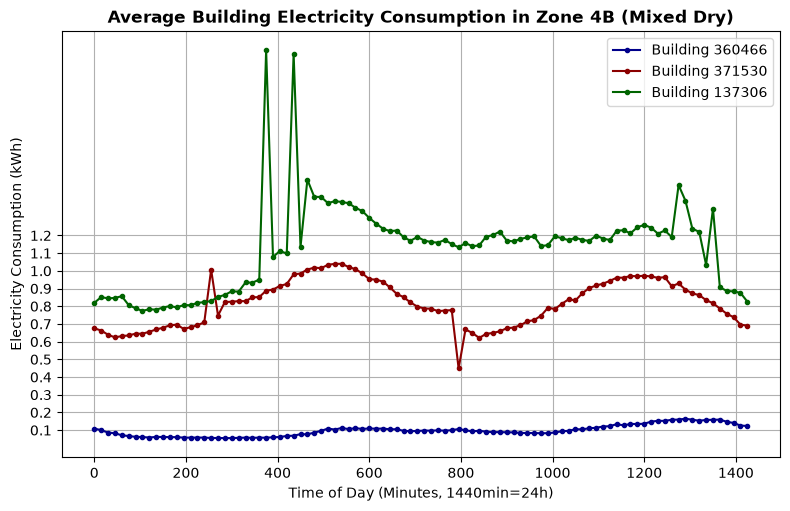

In [224]:
make_3_curb_emission_plot(21,22,23)
plt.title('Average Building Electricity Consumption in Zone 4B (Mixed Dry)', fontsize=12, fontweight='bold')
plt.show()

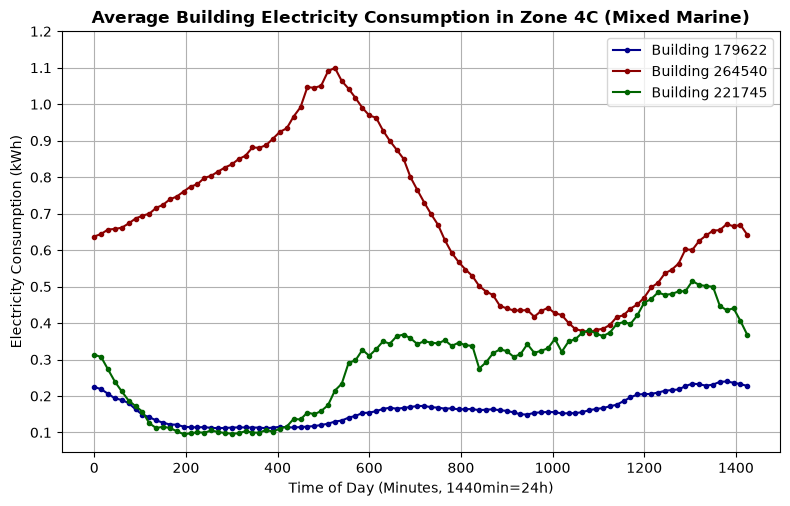

In [225]:
make_3_curb_emission_plot(24,25,26)
plt.title('Average Building Electricity Consumption in Zone 4C (Mixed Marine)', fontsize=12, fontweight='bold')
plt.show()

In [298]:
#On vérifie que la courbe bleue n'est pas vide
df_metadata["in.occupants"].loc[df_metadata["bldg_id"]==221745].iloc[0]

np.float64(2.0)

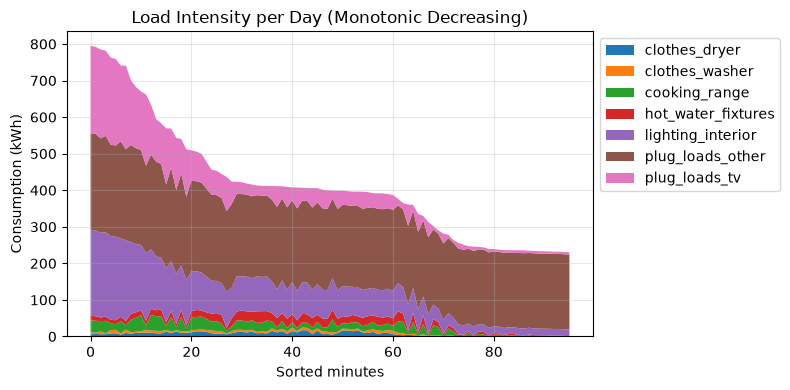

In [288]:
make_mono_plot(24)

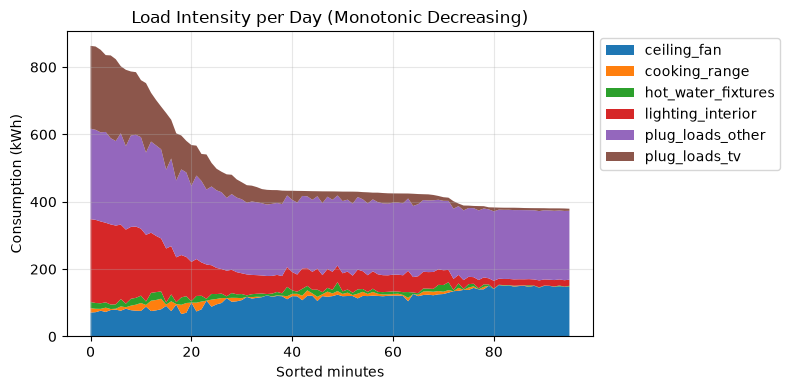

In [289]:
make_mono_plot(25)

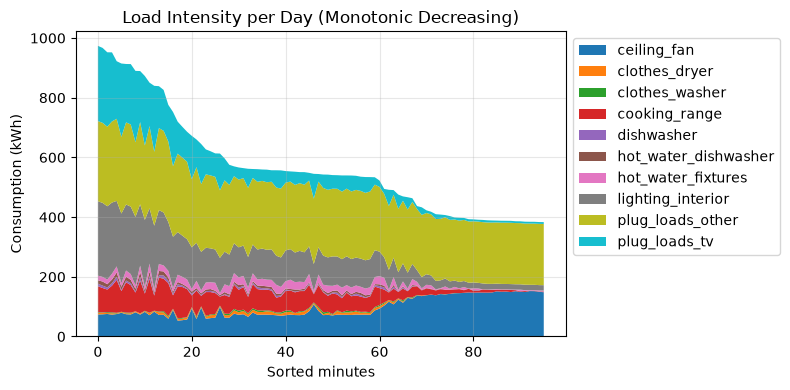

In [290]:
make_mono_plot(26)

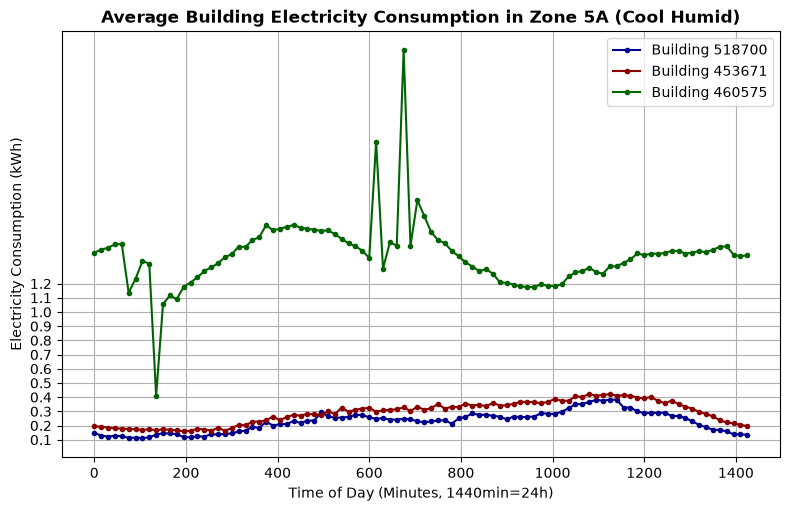

In [226]:
make_3_curb_emission_plot(27,28,29)
plt.title('Average Building Electricity Consumption in Zone 5A (Cool Humid)', fontsize=12, fontweight='bold')
plt.show()

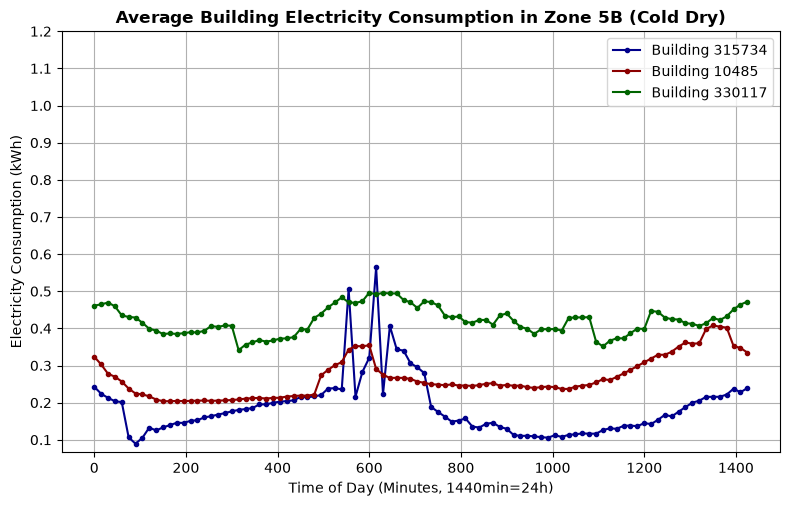

In [227]:
make_3_curb_emission_plot(30,31,32)
plt.title('Average Building Electricity Consumption in Zone 5B (Cold Dry)', fontsize=12, fontweight='bold')
plt.show()

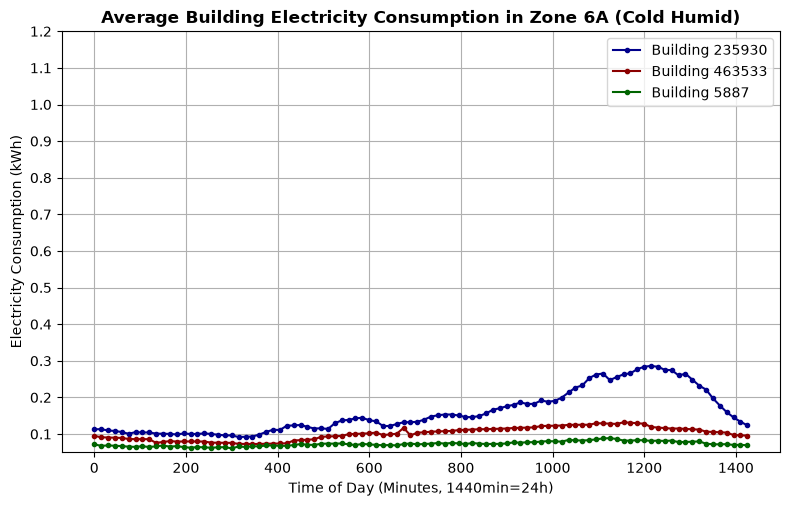

In [228]:
make_3_curb_emission_plot(33,34,35)
plt.title('Average Building Electricity Consumption in Zone 6A (Cold Humid)', fontsize=12, fontweight='bold')
plt.show()

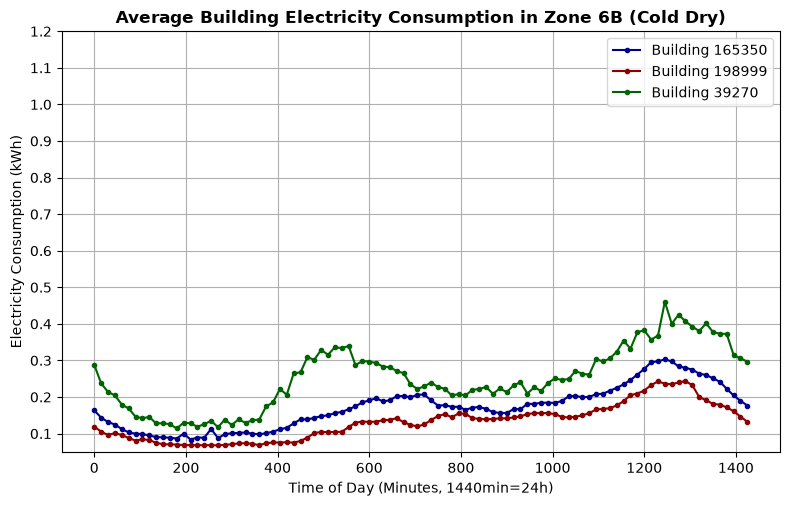

In [229]:
make_3_curb_emission_plot(36,37,38)
plt.title('Average Building Electricity Consumption in Zone 6B (Cold Dry)', fontsize=12, fontweight='bold')
plt.show()

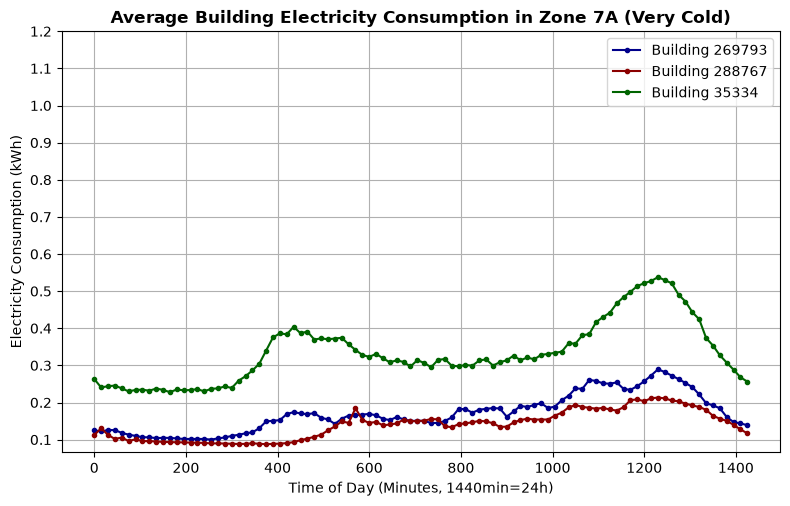

In [230]:
make_3_curb_emission_plot(39,40,41)
plt.title('Average Building Electricity Consumption in Zone 7A (Very Cold)', fontsize=12, fontweight='bold')
plt.show()

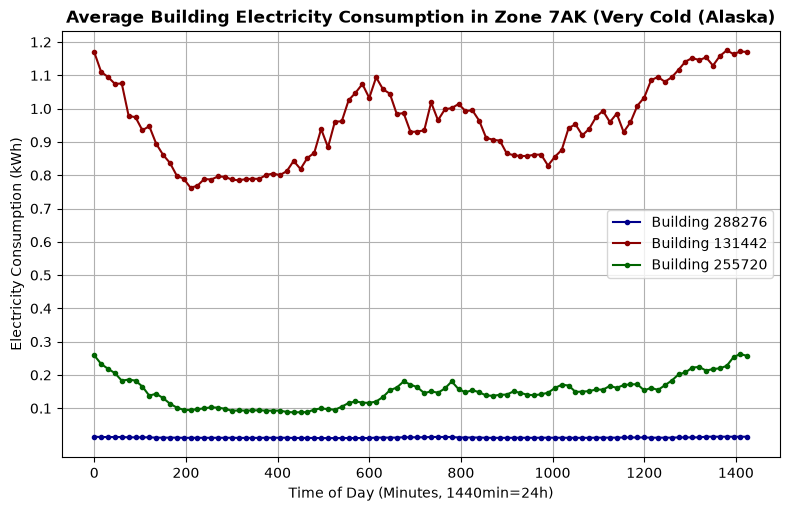

In [231]:
make_3_curb_emission_plot(42,43,44)
plt.title('Average Building Electricity Consumption in Zone 7AK (Very Cold (Alaska)', fontsize=12, fontweight='bold')
plt.show()

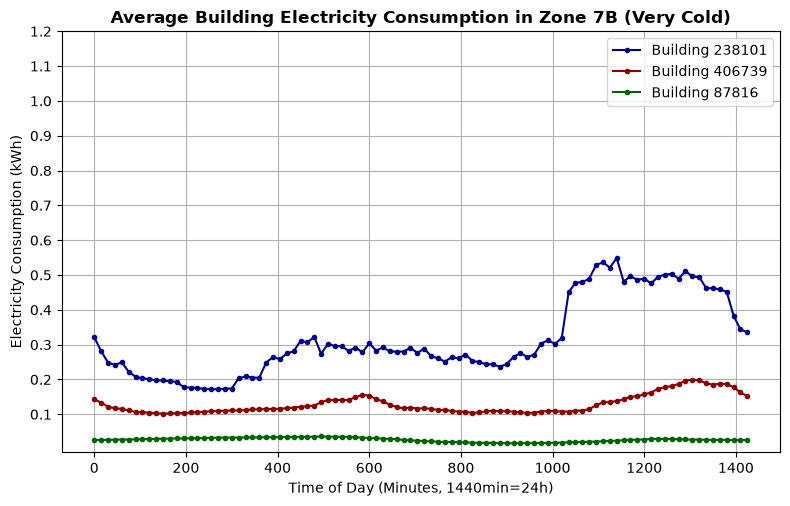

In [232]:
make_3_curb_emission_plot(45,46,47)
plt.title('Average Building Electricity Consumption in Zone 7B (Very Cold)', fontsize=12, fontweight='bold')
plt.show()

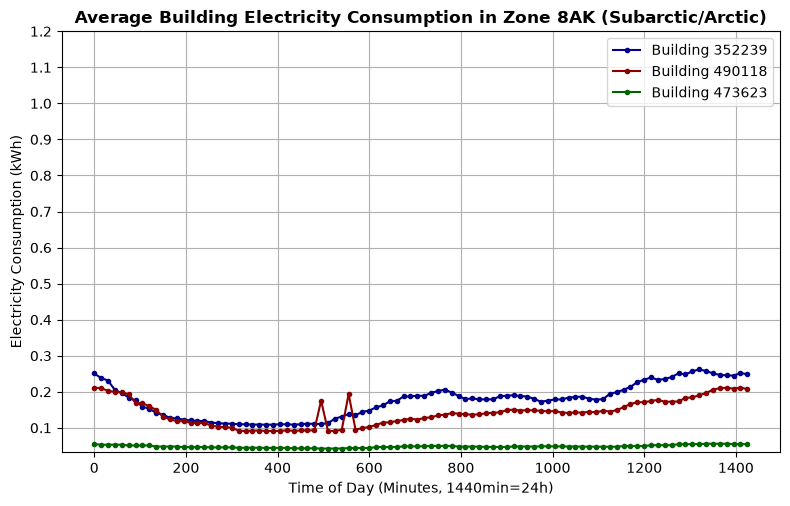

In [233]:
make_3_curb_emission_plot(48,49,50)
plt.title('Average Building Electricity Consumption in Zone 8AK (Subarctic/Arctic)', fontsize=12, fontweight='bold')
plt.show()

### Analyse des variables explicatives des 3 courbes par une courbe monotone décroissante

In [234]:
APPLIANCES = [
'out.schedules.ceiling_fan',
'out.schedules.clothes_dryer',
'out.schedules.clothes_washer',
'out.schedules.cooking_range',
'out.schedules.dishwasher',
'out.schedules.hot_water_dishwasher',
'out.schedules.hot_water_fixtures',
'out.schedules.lighting_interior',
'out.schedules.plug_loads_other',
'out.schedules.plug_loads_tv'
]

In [387]:
def make_mono_plot(index):
    df_app = dataframes[index].copy(deep=True)
    
    for col in df_app.columns.copy():
        if col not in APPLIANCES and col != 'minute' and col != "out.electricity.total.energy_consumption..kwh":
            df_app.drop(columns=col, inplace=True)
        elif pd.isna(df_app[col].iloc[0]):
            df_app.drop(columns=col, inplace=True)

    df_app = df_app.groupby("minute", as_index=False).mean()
    df_app["Total"] = df_app.drop(columns=["minute","out.electricity.total.energy_consumption..kwh"]).sum(axis=1)
    df_app = df_app.sort_values(by="Total", ascending=False).reset_index(drop=True)
    plot_cols = [col for col in df_app.columns if col not in ["minute", "Total", "out.electricity.total.energy_consumption..kwh"]]

    if not plot_cols:
            print(f"Aucune variable à tracer pour le dataframe {index}")
            return
    
    x = range(len(df_app))
    y = [df_app[col].values for col in plot_cols]
    names = [col[14:] for col in plot_cols]

    plt.figure(figsize=(8, 4))
    plt.stackplot(x, *y, labels=names)
    plt.title("Load Intensity per Day (Monotonic Decreasing)")
    plt.xlabel("Sorted minuts")
    plt.ylabel("Consumption (kWh)")
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

1A

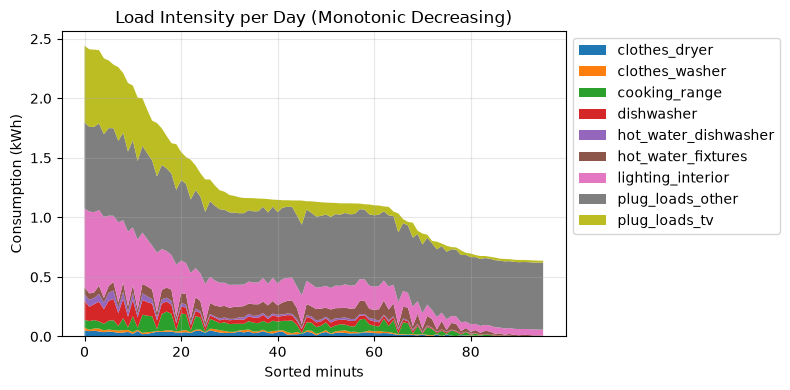

In [388]:
make_mono_plot(0)

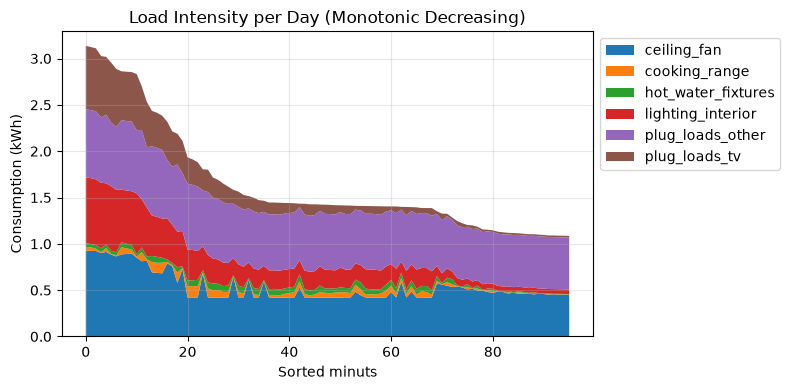

In [389]:
make_mono_plot(1)

In [390]:
make_mono_plot(2)

Aucune variable à tracer pour le dataframe 2


2A

In [391]:
make_mono_plot(3)

Aucune variable à tracer pour le dataframe 3


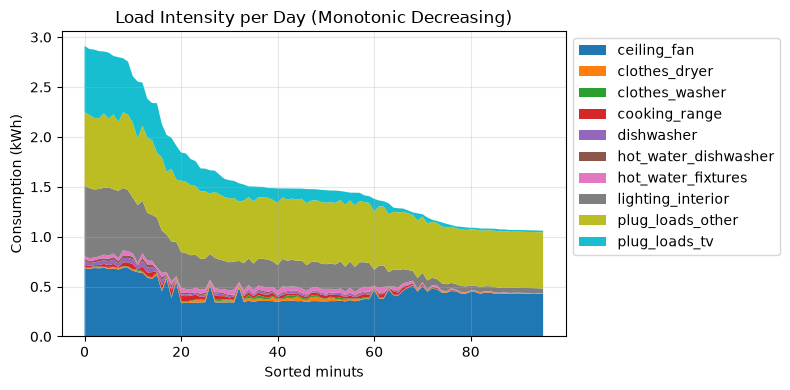

In [392]:
make_mono_plot(4)

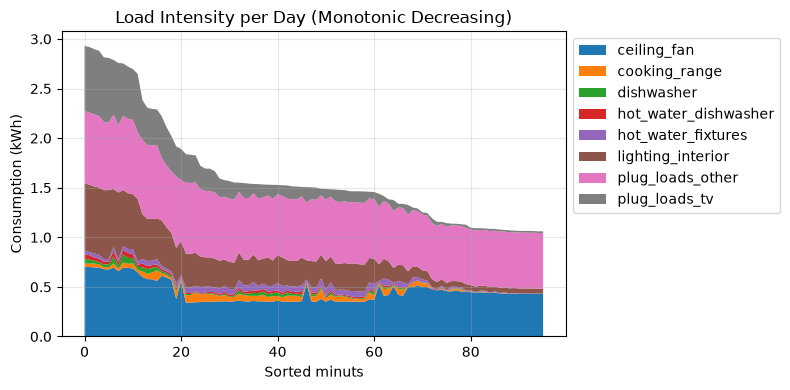

In [393]:
make_mono_plot(5)

2B

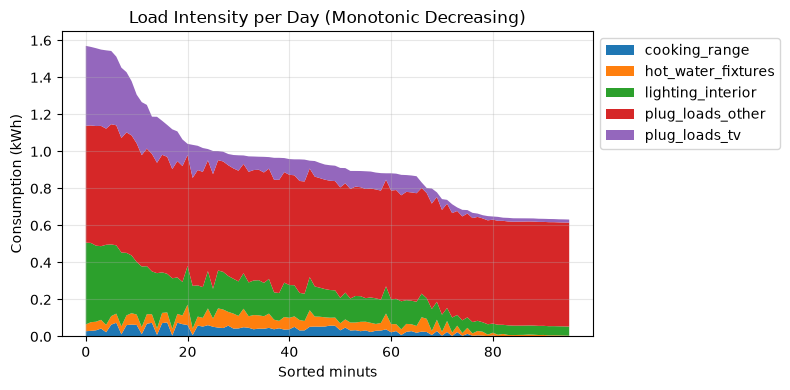

In [394]:
make_mono_plot(6)

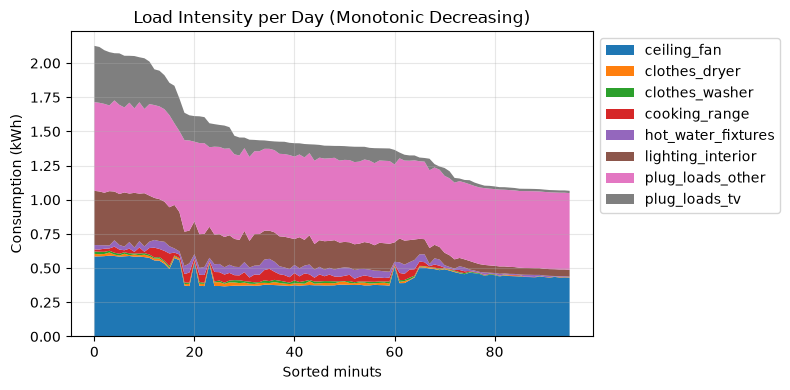

In [395]:
make_mono_plot(7)

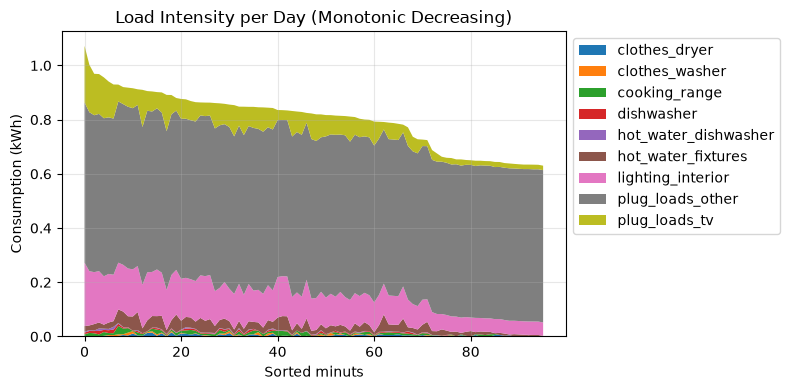

In [396]:
make_mono_plot(8)

3A

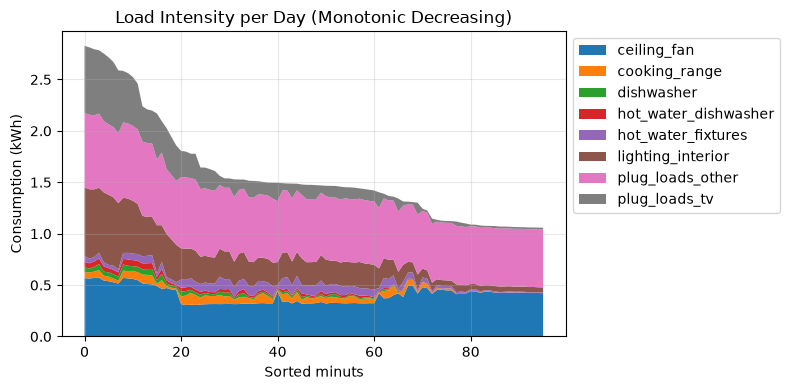

In [397]:
make_mono_plot(9)

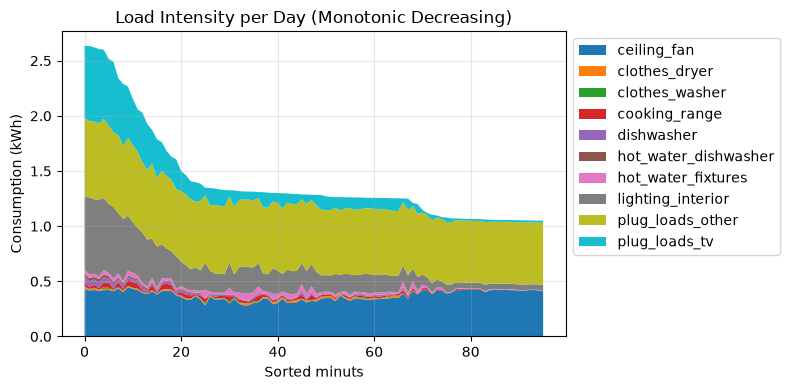

In [398]:
make_mono_plot(10)

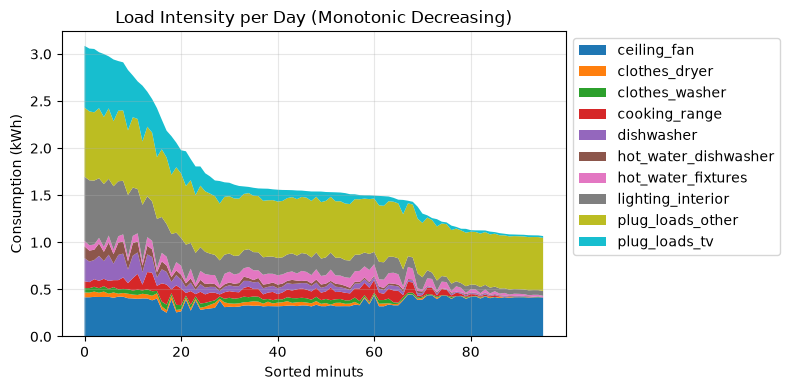

In [399]:
make_mono_plot(11)

3B

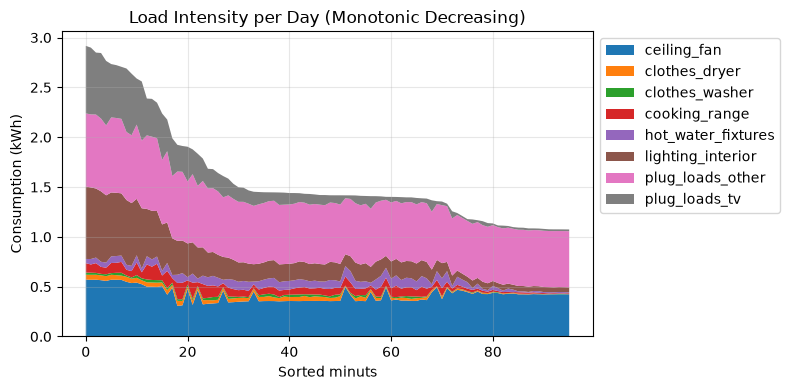

In [400]:
make_mono_plot(12)

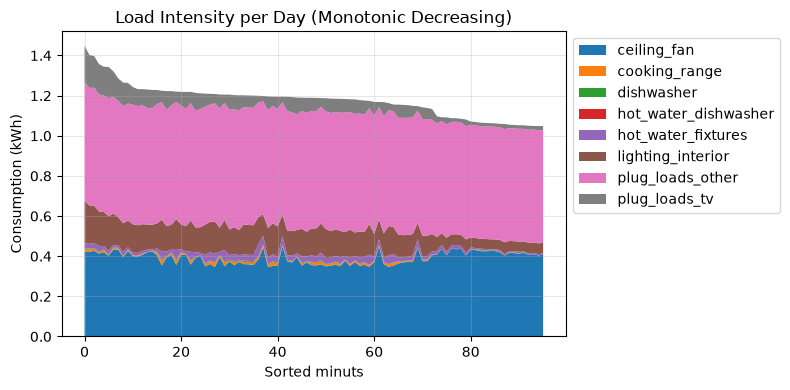

In [401]:
make_mono_plot(13)

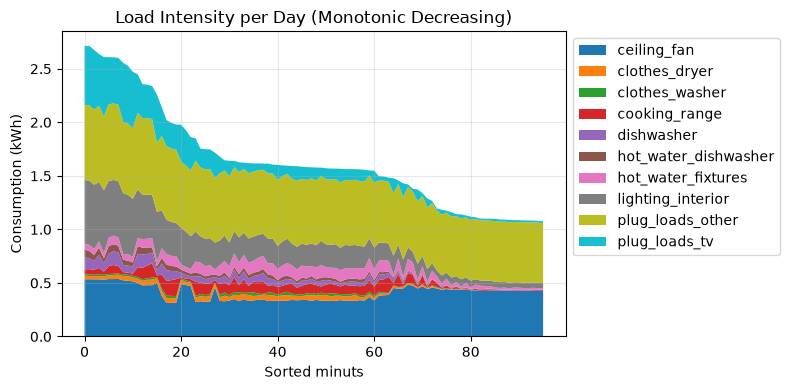

In [402]:
make_mono_plot(14)

3C

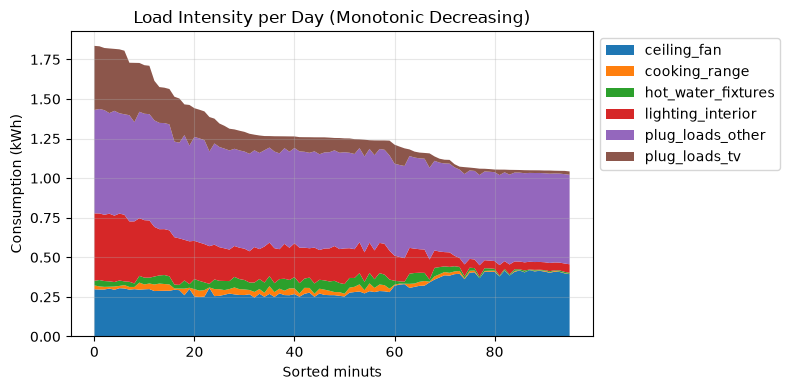

In [403]:
make_mono_plot(15)

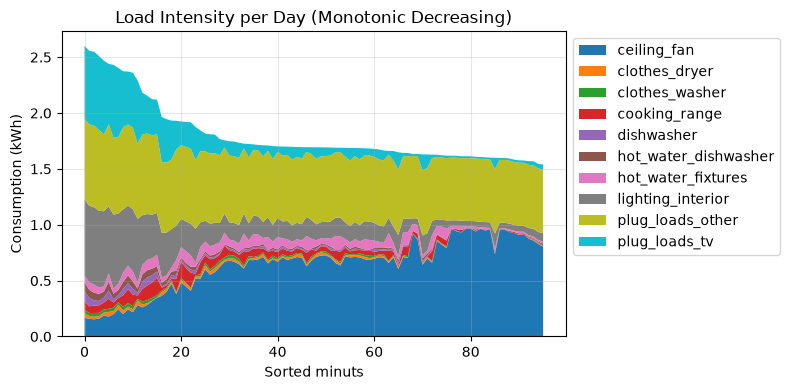

In [404]:
make_mono_plot(16)

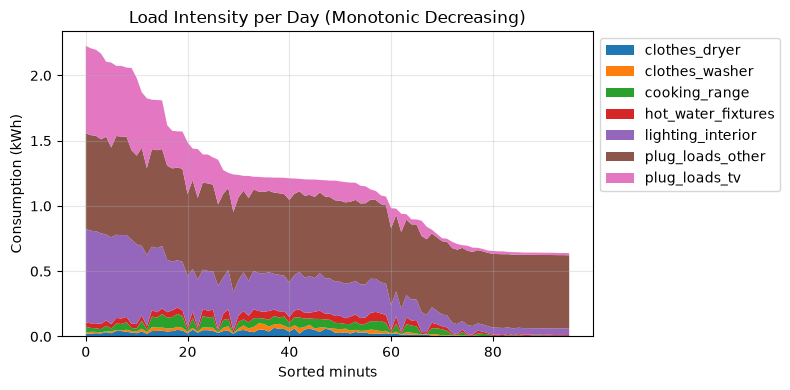

In [405]:
make_mono_plot(17)

4A

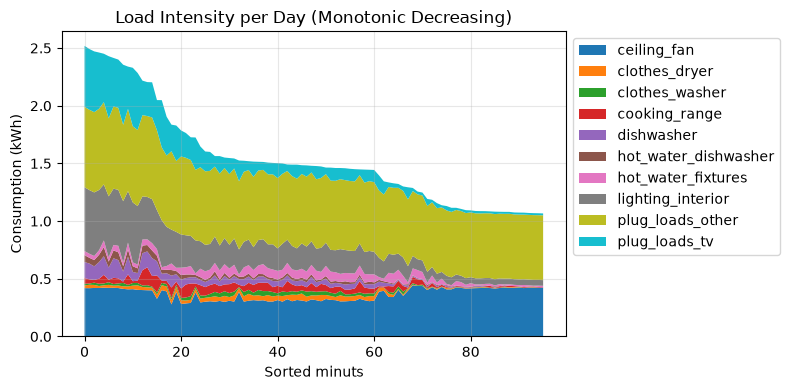

In [406]:
make_mono_plot(18)

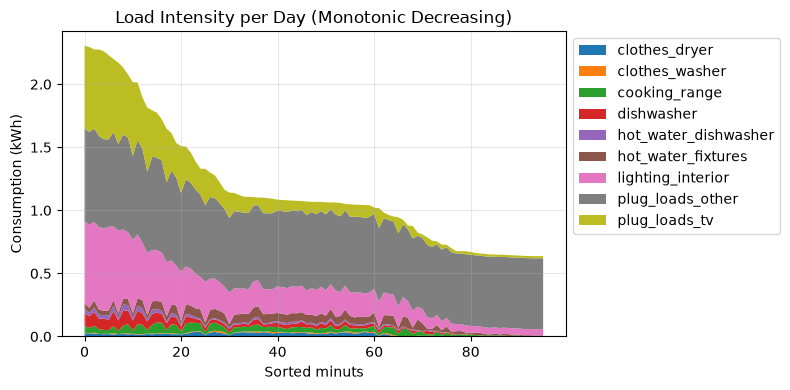

In [407]:
make_mono_plot(19)

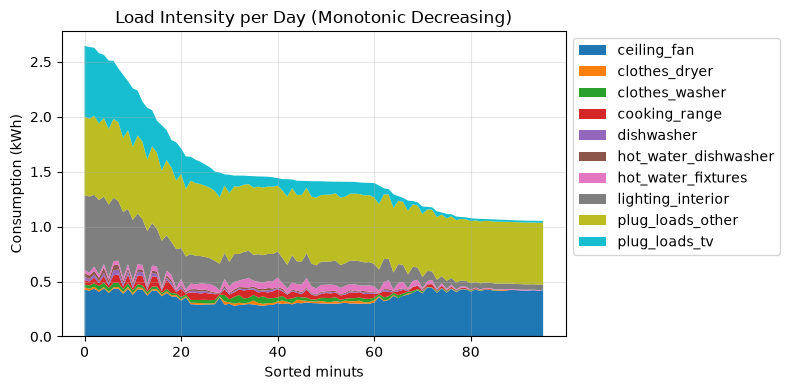

In [408]:
make_mono_plot(20)

4B

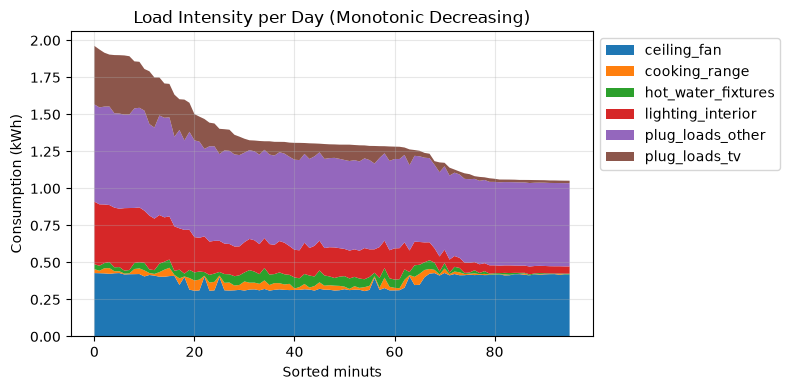

In [409]:
make_mono_plot(21)

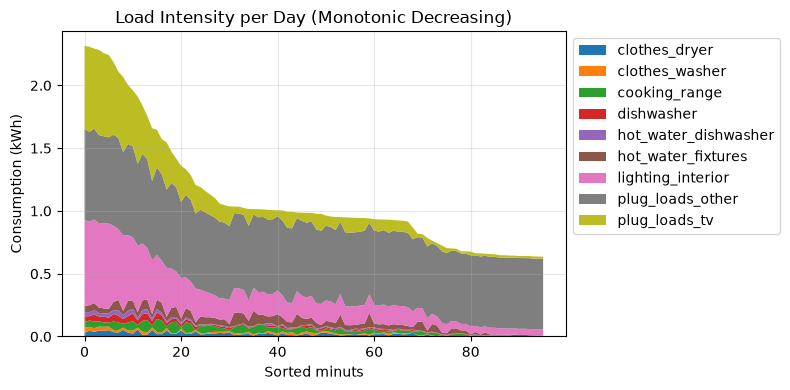

In [410]:
make_mono_plot(22)

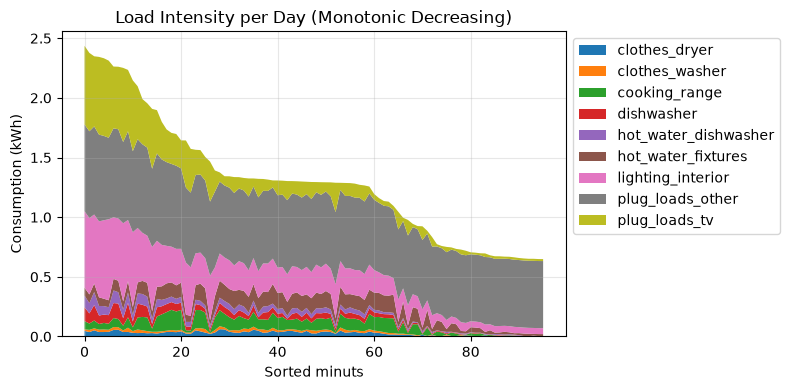

In [411]:
make_mono_plot(23)

4C

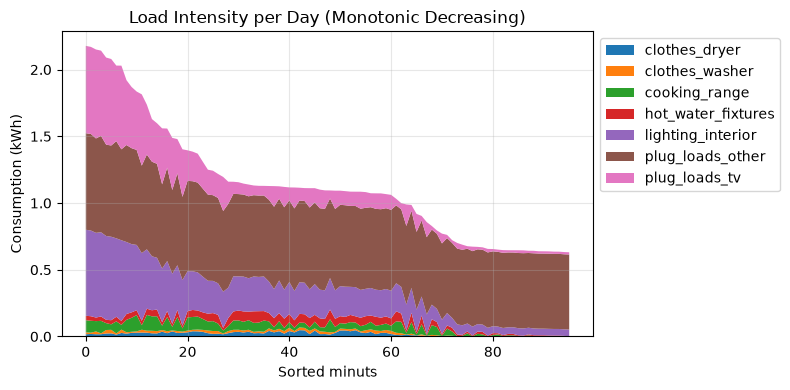

In [412]:
make_mono_plot(24)

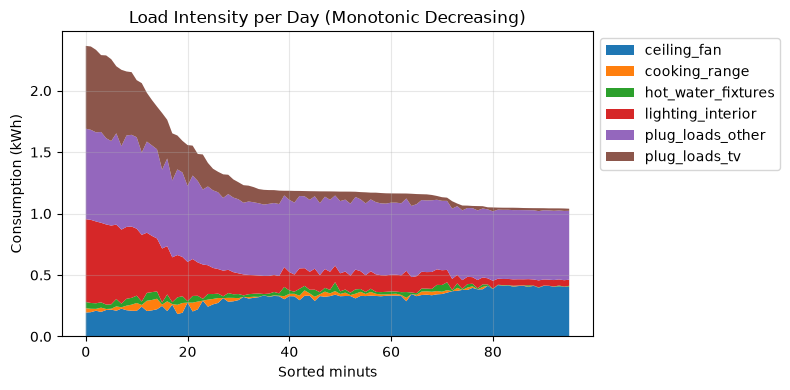

In [413]:
make_mono_plot(25)

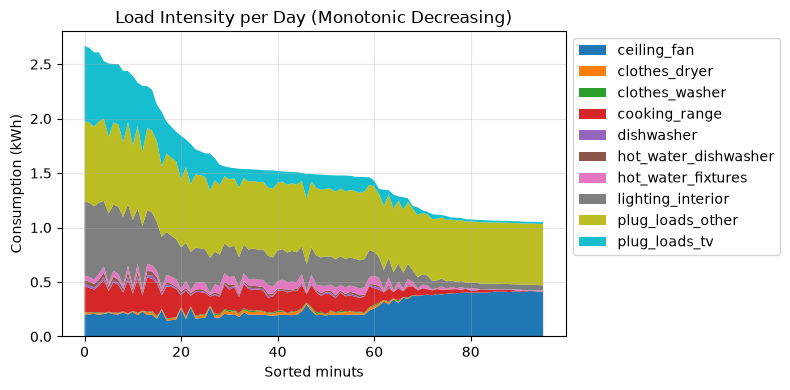

In [414]:
make_mono_plot(26)

5A

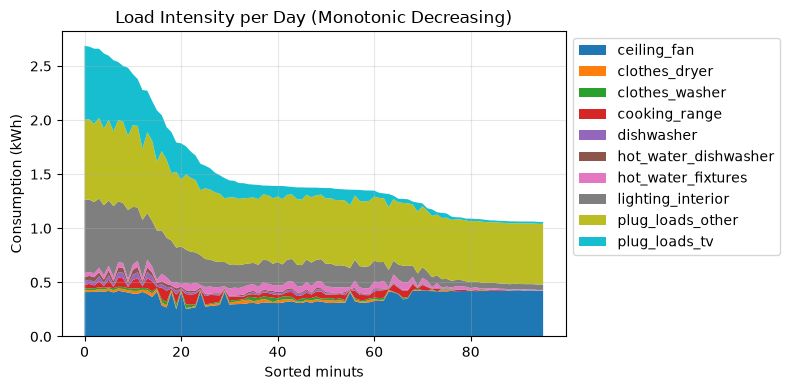

In [415]:
make_mono_plot(27)

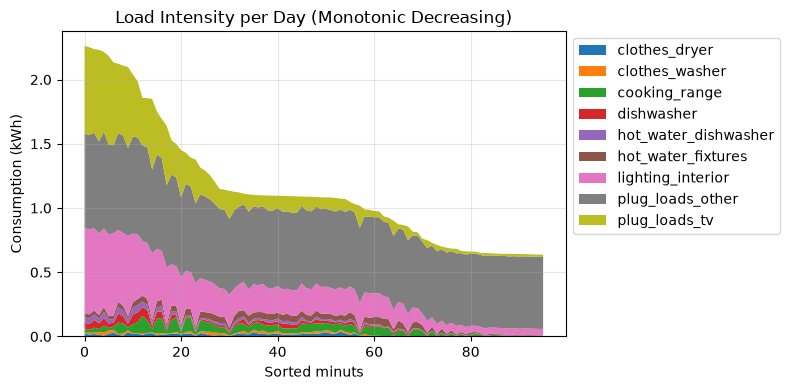

In [416]:
make_mono_plot(28)

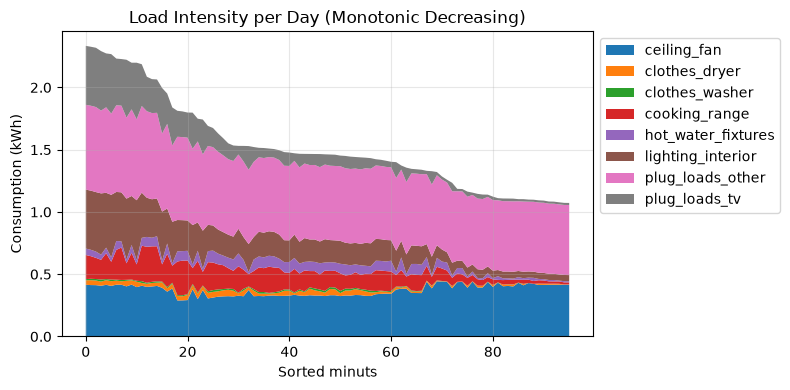

In [417]:
make_mono_plot(29)

5B

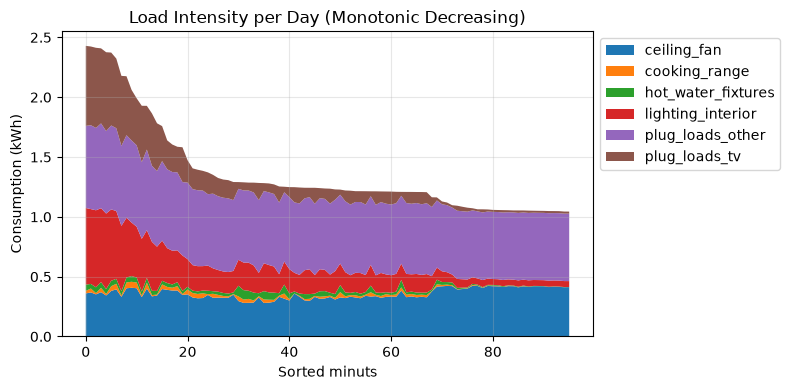

In [418]:
make_mono_plot(30)

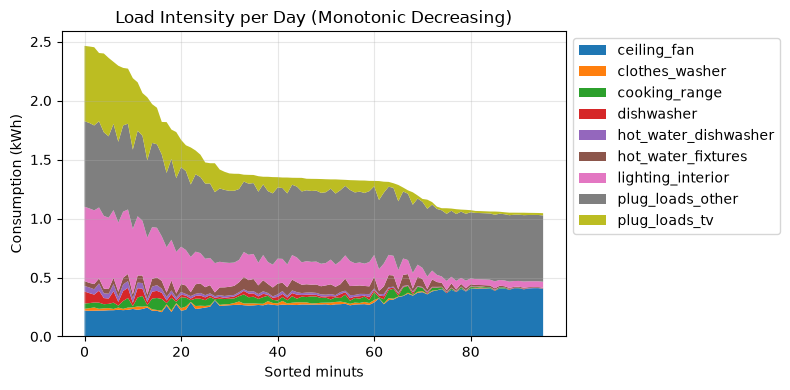

In [419]:
make_mono_plot(31)

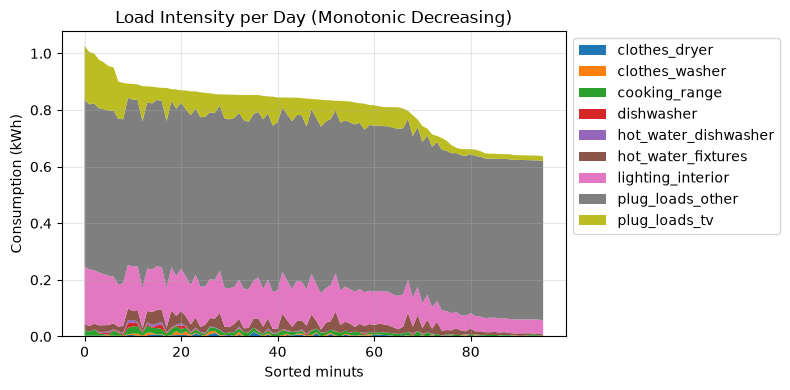

In [420]:
make_mono_plot(32)

6A

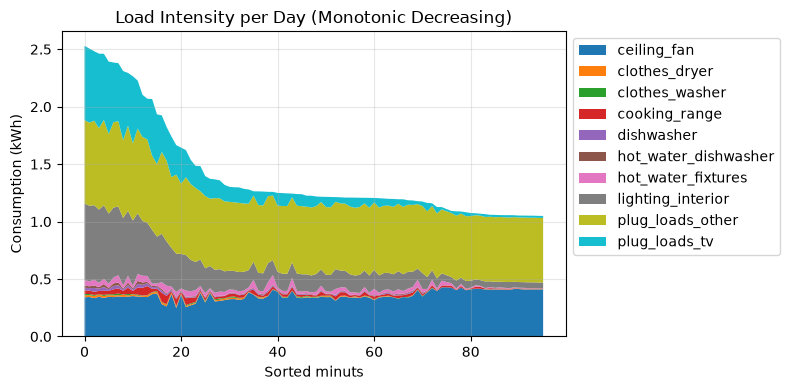

In [421]:
make_mono_plot(33)

In [422]:
make_mono_plot(34)

Aucune variable à tracer pour le dataframe 34


In [423]:
make_mono_plot(35)

Aucune variable à tracer pour le dataframe 35


6B

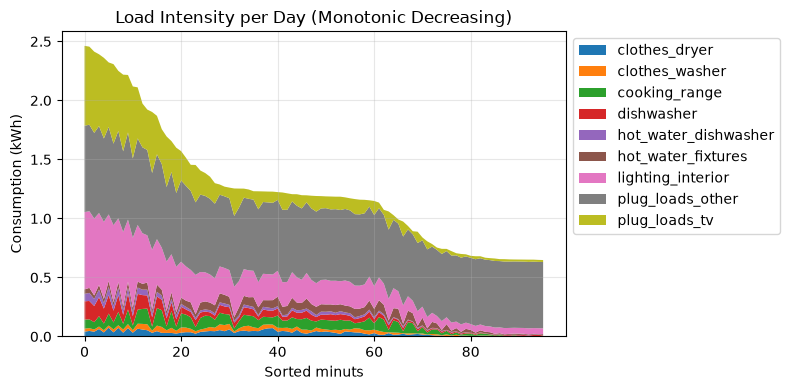

In [424]:
make_mono_plot(36)

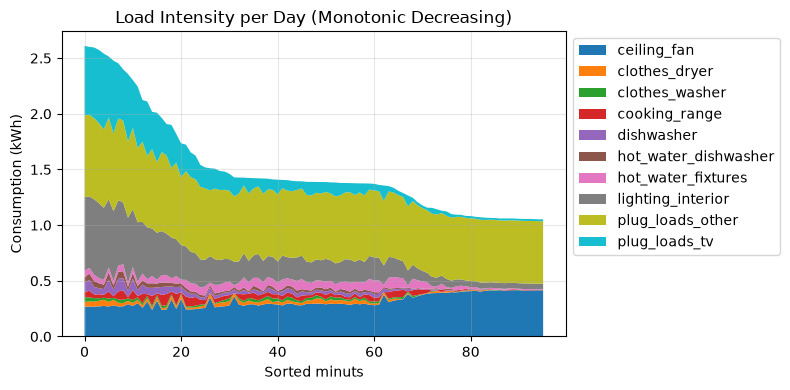

In [425]:
make_mono_plot(37)

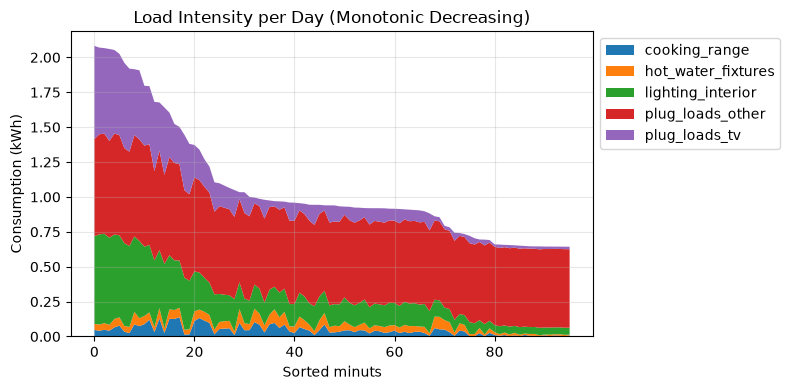

In [426]:
make_mono_plot(38)

7A

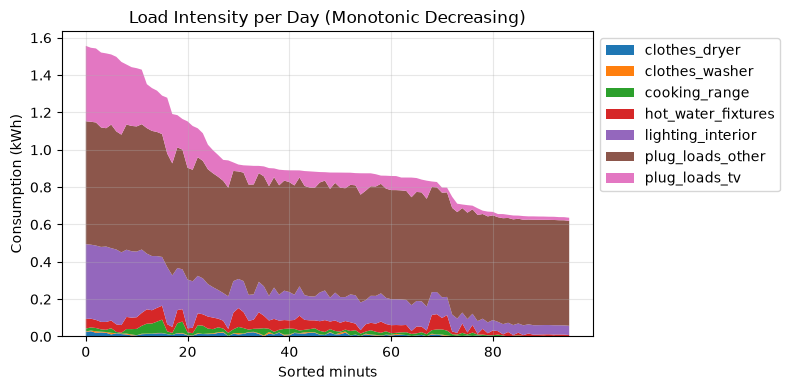

In [427]:
make_mono_plot(39)

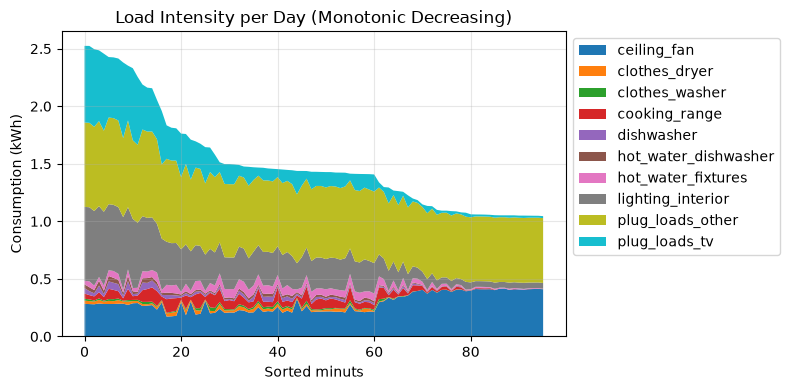

In [428]:
make_mono_plot(40)

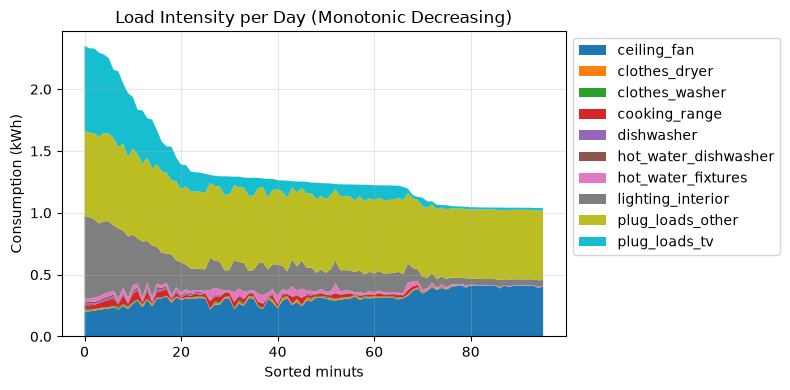

In [429]:
make_mono_plot(41)

7AK

In [430]:
make_mono_plot(42)

Aucune variable à tracer pour le dataframe 42


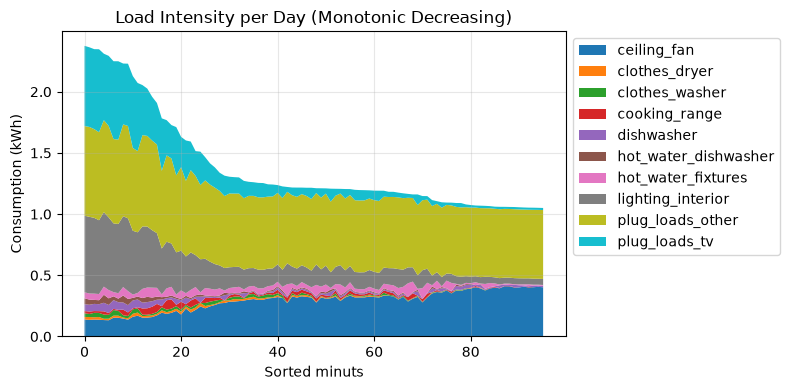

In [431]:
make_mono_plot(43)

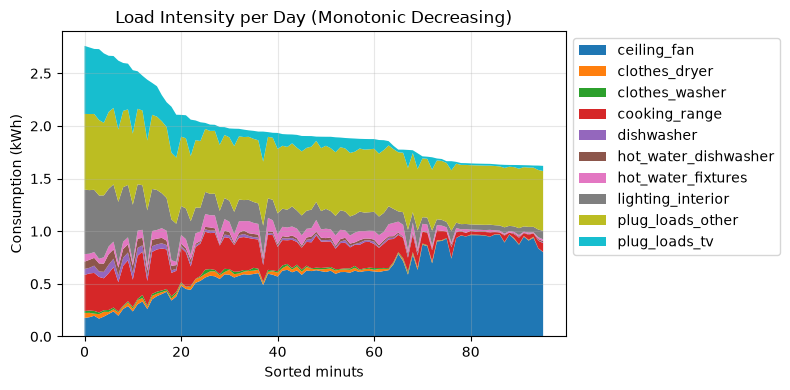

In [432]:
make_mono_plot(44)

7B

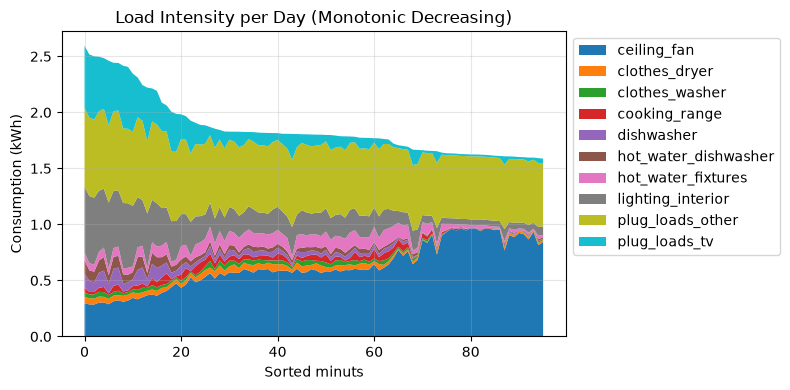

In [433]:
make_mono_plot(45)

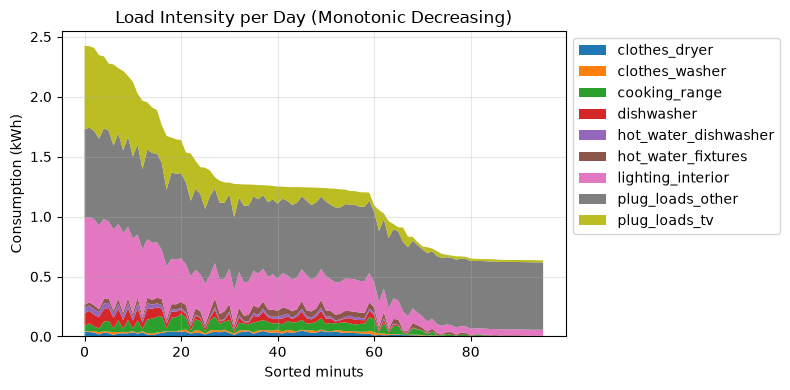

In [434]:
make_mono_plot(46)

In [435]:
make_mono_plot(47)

Aucune variable à tracer pour le dataframe 47


8AK

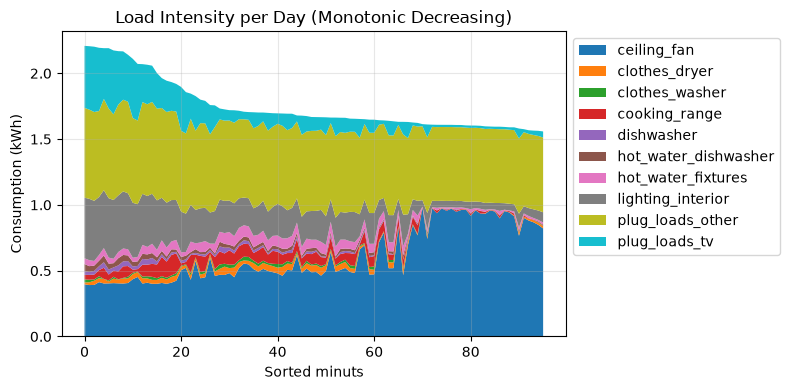

In [436]:
make_mono_plot(48)

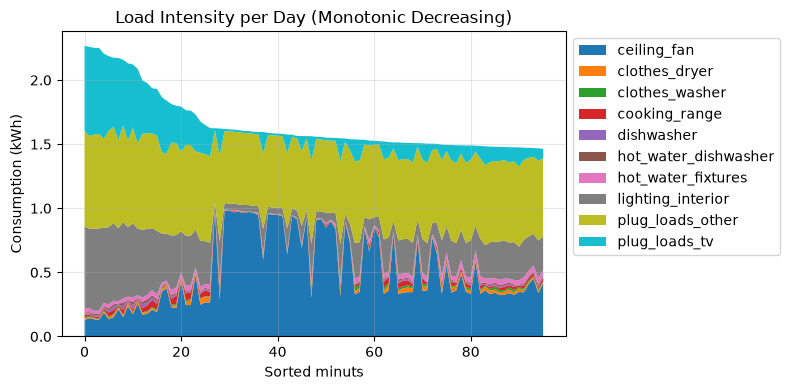

In [437]:
make_mono_plot(49)

In [438]:
make_mono_plot(50)

Aucune variable à tracer pour le dataframe 50


### II. Corrélations entre variables de df_metadata

Matrice /df de covariance au sein d'un bâtiment, entre différentes variables. 

Moyenne : Trouver la moyenne de la série de données.
Écarts au carré : Soustraire la moyenne à chaque valeur, puis mettre le résultat au carré.
Somme et division : Additionner ces carrés et diviser par le nombre total de valeurs.

In [450]:
pearson_corr = dataframes[24].drop(columns = ['timestamp', 'date', 'minute'])
pearson_corr = pearson_corr.corr(method='pearson')
print("Pearson Correlation:")
pearson_corr

Pearson Correlation:


,bldg_id,in.sqft,out.electricity.ceiling_fan.energy_consumption..kwh,out.electricity.clothes_dryer.energy_consumption..kwh,out.electricity.clothes_washer.energy_consumption..kwh,out.electricity.cooling.energy_consumption..kwh,out.electricity.cooling_fans_pumps.energy_consumption..kwh,out.electricity.dishwasher.energy_consumption..kwh,out.electricity.ev_charging.energy_consumption..kwh,out.electricity.freezer.energy_consumption..kwh,...,out.schedules.lighting_interior,out.schedules.no_space_cooling,out.schedules.no_space_heating,out.schedules.occupants,out.schedules.peak_period,out.schedules.plug_loads_other,out.schedules.plug_loads_tv,out.schedules.power_outage,out.schedules.pre_peak_period,out.schedules.vacancy
bldg_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
in.sqft,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
out.electricity.ceiling_fan.energy_consumption..kwh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
out.electricity.clothes_dryer.energy_consumption..kwh,NaN,NaN,NaN,1.000000,0.058739,0.013873,NaN,NaN,NaN,0.038599,...,0.077195,NaN,NaN,-0.037753,NaN,0.047210,0.046683,NaN,NaN,NaN
out.electricity.clothes_washer.energy_consumption..kwh,NaN,NaN,NaN,0.058739,1.000000,0.017463,NaN,NaN,NaN,0.036279,...,0.064336,NaN,NaN,-0.016464,NaN,0.035268,0.047414,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
out.schedules.plug_loads_other,NaN,NaN,NaN,0.047210,0.035268,-0.106496,NaN,NaN,NaN,-0.047974,...,0.744950,NaN,NaN,0.055701,NaN,1.000000,0.637121,NaN,NaN,NaN
out.schedules.plug_loads_tv,NaN,NaN,NaN,0.046683,0.047414,0.177743,NaN,NaN,NaN,0.390404,...,0.874898,NaN,NaN,0.179249,NaN,0.637121,1.000000,NaN,NaN,NaN
out.schedules.power_outage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
out.schedules.pre_peak_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


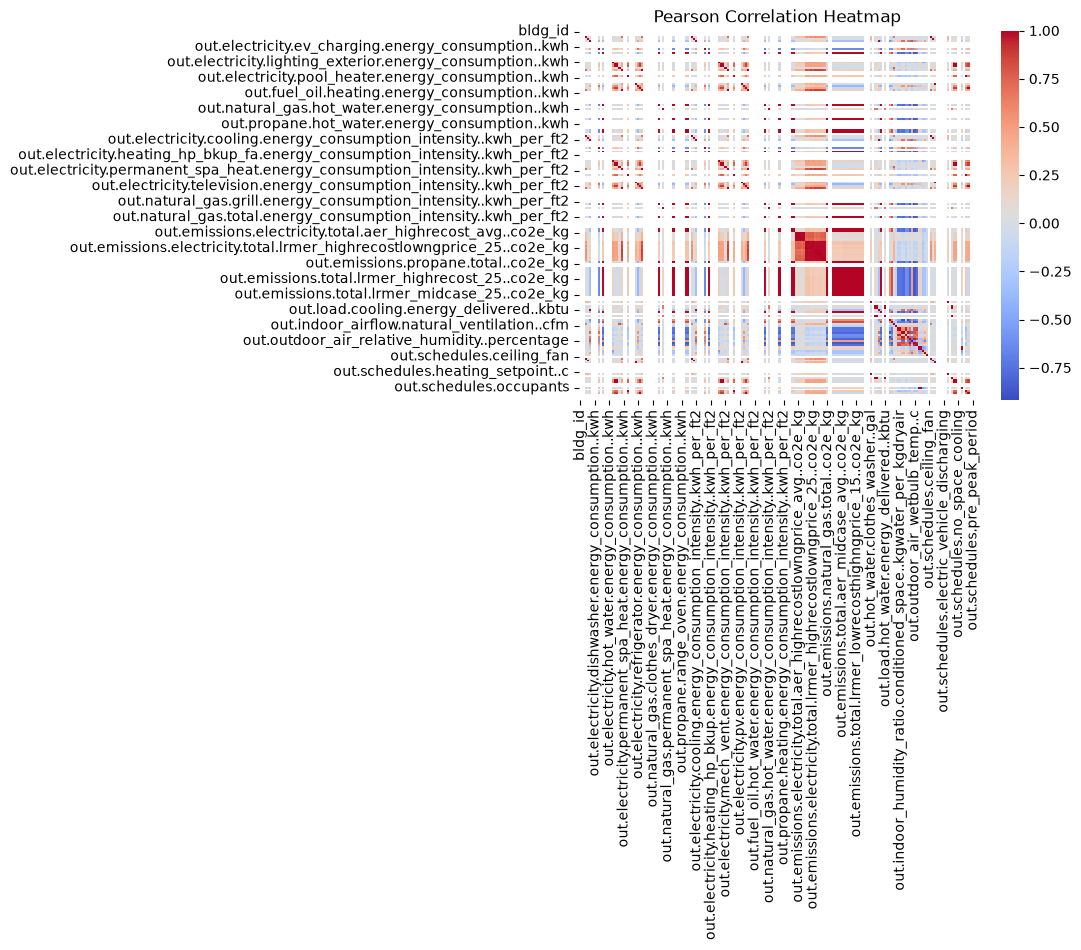

In [449]:
sns.heatmap(pearson_corr, annot=False, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()

In [492]:
corr_w_total = pearson_corr["out.electricity.total.energy_consumption..kwh"].dropna()
corr_w_total

out.electricity.clothes_dryer.energy_consumption..kwh         0.709207
out.electricity.clothes_washer.energy_consumption..kwh        0.110311
out.electricity.cooling.energy_consumption..kwh               0.271131
out.electricity.freezer.energy_consumption..kwh               0.168901
out.electricity.heating_fans_pumps.energy_consumption..kwh    0.141436
                                                                ...   
out.schedules.lighting_garage                                 0.461976
out.schedules.lighting_interior                               0.461976
out.schedules.occupants                                       0.012484
out.schedules.plug_loads_other                                0.391406
out.schedules.plug_loads_tv                                   0.436526
Name: out.electricity.total.energy_consumption..kwh, Length: 106, dtype: float64

In [510]:
corr_w_total_IMPORTANT1 = corr_w_total[corr_w_total >= 0.7]
corr_w_total_IMPORTANT2 = corr_w_total[corr_w_total<=-0.7]
corr_w_total_IMPORTANT = pd.concat([corr_w_total_IMPORTANT1,corr_w_total_IMPORTANT2],ignore_index=False)
corr_w_total_IMPORTANT

out.electricity.clothes_dryer.energy_consumption..kwh                      0.709207
out.electricity.net.energy_consumption..kwh                                1.000000
out.electricity.total.energy_consumption..kwh                              1.000000
out.electricity.clothes_dryer.energy_consumption_intensity..kwh_per_ft2    0.709207
out.electricity.net.energy_consumption_intensity..kwh_per_ft2              1.000000
out.electricity.total.energy_consumption_intensity..kwh_per_ft2            1.000000
out.emissions.electricity.total.lrmer_highrecost_15..co2e_kg               0.827137
out.emissions.electricity.total.lrmer_highrecost_25..co2e_kg               0.783617
out.emissions.electricity.total.lrmer_highrecostlowngprice_15..co2e_kg     0.859512
out.emissions.electricity.total.lrmer_highrecostlowngprice_25..co2e_kg     0.806165
out.emissions.electricity.total.lrmer_lowrecost_15..co2e_kg                0.887572
out.emissions.electricity.total.lrmer_lowrecost_25..co2e_kg                0

In [494]:
corr_w_total_MID = corr_w_total[0.4<corr_w_total]
corr_w_total_MID1 = corr_w_total_MID[corr_w_total_MID<0.7]
corr_w_total_MID=corr_w_total[-0.4>corr_w_total]
corr_w_total_MID2 = corr_w_total_MID[corr_w_total_MID>-0.7]
corr_w_total_MID=pd.concat([corr_w_total_MID2,corr_w_total_MID1])
corr_w_total_MID

out.electricity.lighting_garage.energy_consumption..kwh                        0.462112
out.electricity.lighting_interior.energy_consumption..kwh                      0.462099
out.electricity.range_oven.energy_consumption..kwh                             0.494736
out.electricity.television.energy_consumption..kwh                             0.436725
out.electricity.lighting_garage.energy_consumption_intensity..kwh_per_ft2      0.462112
out.electricity.lighting_interior.energy_consumption_intensity..kwh_per_ft2    0.462099
out.electricity.range_oven.energy_consumption_intensity..kwh_per_ft2           0.494736
out.electricity.television.energy_consumption_intensity..kwh_per_ft2           0.436725
out.emissions.electricity.total.aer_highrecost_avg..co2e_kg                    0.403495
out.emissions.electricity.total.aer_highrecostlowngprice_avg..co2e_kg          0.404986
out.emissions.electricity.total.aer_lowrecost_avg..co2e_kg                     0.407057
out.emissions.electricity.total.

In [495]:
corr_w_total_LOW1 = corr_w_total[corr_w_total <0.4]
corr_w_total_LOW2 = corr_w_total[corr_w_total>-0.4]
corr_w_total_LOW = pd.concat([corr_w_total_LOW1,corr_w_total_LOW2],ignore_index=False)
corr_w_total_LOW

out.electricity.clothes_washer.energy_consumption..kwh        0.110311
out.electricity.cooling.energy_consumption..kwh               0.271131
out.electricity.freezer.energy_consumption..kwh               0.168901
out.electricity.heating_fans_pumps.energy_consumption..kwh    0.141436
out.electricity.lighting_exterior.energy_consumption..kwh     0.312810
                                                                ...   
out.schedules.lighting_garage                                 0.461976
out.schedules.lighting_interior                               0.461976
out.schedules.occupants                                       0.012484
out.schedules.plug_loads_other                                0.391406
out.schedules.plug_loads_tv                                   0.436526
Name: out.electricity.total.energy_consumption..kwh, Length: 178, dtype: float64

In [ ]:
corr_w_total_MID.size + corr_w_total_IMPORTANT.size + corr_w_total_LOW.size == len(corr_w_total)*2
#pas normal il doit faire 2 

True

### III. Différences et similitudes entre le bâtiment moyen de zones ASHRAE différentes

In [439]:
df_metadata.groupby("in.ashrae_iecc_climate_zone_2004").mean(numeric_only=True)
#par_etat = df_metadata.groupby('in.state', as_index=False).agg(nb=(CONSO_COL, 'count'),conso_moy=(CONSO_COL, 'mean')).sort_values('nb', ascending=False).head(20)

,bldg_id,upgrade,weight,applicability,in.sqft..ft2,in.representative_income,in.aiannh_area,in.bathroom_spot_vent_hour,in.bedrooms,in.clothes_dryer_usage_level,...,out.propane.hot_water.energy_consumption_intensity..kwh_per_ft2,out.propane.range_oven.energy_consumption_intensity..kwh_per_ft2,out.propane.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.net.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,in.slab_perimeter_r,in.slab_under_r,in.duct_leakage,in.duct_insulation,in.duct_location_int
in.ashrae_iecc_climate_zone_2004,,,,,,,,,,,,,,,,,,,,,
1A,275131.423744,0.0,253.903673,1.0,1490.732217,86183.773438,0.003856,11.114155,2.483409,1.003044,...,0.033040,0.017369,0.054011,8.480225,8.750102,0.242009,0.602740,0.097378,1.261695,2.179097
2A,275980.366247,0.0,253.903673,1.0,1677.693929,77383.664062,0.005677,10.940153,2.775763,0.999275,...,0.046709,0.014433,0.106366,10.680764,10.701381,0.339460,0.755454,0.124685,2.583379,3.350627
2B,277383.943457,0.0,253.903673,1.0,1812.311907,79009.609375,0.00663,10.973570,2.841054,1.000424,...,0.034119,0.012119,0.058039,10.588064,10.769260,0.381251,0.471038,0.125251,2.912975,3.271572
3A,275285.895514,0.0,253.903673,1.0,1692.800456,72897.531250,0.083073,11.004892,2.828976,1.000599,...,0.074145,0.018047,0.402980,13.387066,13.394278,0.246389,0.491275,0.138856,2.031895,3.298072
3B,274750.884327,0.0,253.903673,1.0,1548.949923,91666.406250,0.003014,11.021780,2.648539,0.999076,...,0.065178,0.016863,0.154090,10.655740,10.882327,0.215358,0.288448,0.139107,1.765484,2.768341
3C,277001.096944,0.0,253.903673,1.0,1515.077943,136269.734375,0.000155,11.031177,2.597410,0.999100,...,0.073037,0.020057,0.176593,10.431785,10.612984,0.113231,0.179153,0.140148,1.106251,2.462463
4A,274800.808565,0.0,253.903673,1.0,1637.773164,89115.062500,0.001588,10.997771,2.688429,1.000225,...,0.077047,0.019511,0.561529,17.018915,17.039168,0.382845,0.275850,0.117033,0.964785,2.326003
4B,275480.514346,0.0,253.903673,1.0,1671.424271,69012.890625,0.009643,10.808796,2.821731,1.006820,...,0.302858,0.037185,1.338502,14.840714,14.979574,0.199906,0.298683,0.134757,1.912512,2.980950
4C,273693.332639,0.0,253.903673,1.0,1583.756439,95503.125000,0.016098,10.809533,2.703283,1.000189,...,0.098522,0.033014,0.330781,13.476229,13.497549,0.666035,0.268308,0.147365,1.120960,2.217740
